# Streaming Lars Forward Return

Build LOB features from MBO data, add a forward-return target, then run rolling time-series validation with the streaming `Lars(/Ridge)Adapter`.

In [1]:
from __future__ import annotations

import sys
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import polars as pl

from tools.data import DateFrame, RAW_PATH, Raw
from tools.features import LOBFeatures, add_features, depth_meta
from tools.filters import intraday_time, level_taken, tight_spread, trade_size
from tools.model import LarsAdapter, RidgeAdapter
from tools.pipeline import Pipeline, get_unit_pnl, rmse
from tools.price import add_return
from tools.search import loguniform, grid
from tools.transform import Standardizer


In [2]:
from tools.data import expand_dates

expand_dates('20260501-20260507')

['2026-05-01', '2026-05-04', '2026-05-05', '2026-05-06', '2026-05-07']

In [ ]:
def divide_dates(*args):
    dates = []
    for i in range(1, len(args)):
        dates.append

In [3]:
# Data
PROD = "ES"
# ROLLING_DATES = [['2026-05-01', '2026-05-04', '2026-05-05'], ["2026-05-06"], ["2026-05-07"]]
ROLLING_DATES = 
TEST_DATES = ["2026-05-06"]
L2_DEPTH = 5
MODEL_BATCH_SIZE = 20_000
POLARS_ENGINE = "gpu"
ORDERBOOK_PATH = str(ROOT / f"data/orderbook_l2_parquet/{{prod}}M6_{{d}}_{{tag}}_{{prod_s}}_full_day_l2_d{L2_DEPTH}.parquet")
RAW_CONTEXT_COLS = ("ts_event", "ts_recv", "symbol")
REGULAR_HOURS_START = "09:30"
REGULAR_HOURS_END = "16:00"
REGULAR_HOURS_TZ = "America/New_York"

# Feature knobs
IMBALANCE_DEPTHS = [1, 3, 5]
IMBALANCE_LOG = True
TRADE_MOMENTUM_LOG = True
WEIGHTED_PRICE_DEPTH = 5
WEIGHTED_PRICE_SIZES = [2, 5, 10]
TRADE_MOMENTUM_HALF_LIVES = [1, 10, 30, 120]  # seconds

# Forward-return target knobs
FUTURE_HORIZONS = ["10s", "30s", "60s"]
FUTURE_WEIGHTS = [0.5, 0.3, 0.2]
TARGET = "forward_mid_return_bps"
TEST_PNL_THRESHOLD = 0.3

# Lars/search knobs
SAMPLER = "random"
# SAMPLER = "grid"
N_TRIALS = 5
SEARCH_SPACE = {"alpha": loguniform(1e-2, 10)}
# SEARCH_SPACE = {"alpha": grid([0])}

UNDEF_PRICE = 9_223_372_036_854_775_807
assert L2_DEPTH >= max([*IMBALANCE_DEPTHS, WEIGHTED_PRICE_DEPTH])


In [4]:
def tag(x: object) -> str:
    return str(x).replace(".", "p")


def feature_exprs() -> dict[str, pl.Expr]:
    exprs = {}
    for depth in IMBALANCE_DEPTHS:
        exprs[f"imb_d{depth}"] = LOBFeatures.book_imbalance(depth, log=IMBALANCE_LOG)
    for size in sorted(set([*WEIGHTED_PRICE_SIZES])):
        exprs[f"weighted_price_sz{tag(size)}"] = LOBFeatures.size_weighted_avg_price(WEIGHTED_PRICE_DEPTH, size)
    for half_life in TRADE_MOMENTUM_HALF_LIVES:
        exprs[f"trade_momentum_hl{tag(half_life)}s"] = LOBFeatures.trade_momentum(half_life, log=TRADE_MOMENTUM_LOG)
    return exprs


FEATURE_EXPRS = feature_exprs()
FEATURES = list(FEATURE_EXPRS)
###
# FEATURES = ["imb_d1"]
###
MID = (pl.col("bid_px_0") + pl.col("ask_px_0")) / 2
META_COLS = ["ts_event", "ts_recv", "symbol", *depth_meta(L2_DEPTH)]
VALID_ROWS = (
    (pl.col("bid_px_0") != UNDEF_PRICE)
    & (pl.col("ask_px_0") != UNDEF_PRICE)
    & pl.col(TARGET).is_not_null()
    & pl.all_horizontal([pl.col(c).is_finite() for c in FEATURES])
)
REGULAR_HOURS = intraday_time(REGULAR_HOURS_START, REGULAR_HOURS_END, timezone=REGULAR_HOURS_TZ)
TIGHT_SPREAD = tight_spread(25)
VALID_REGULAR_ROWS = VALID_ROWS & REGULAR_HOURS & TIGHT_SPREAD
TRAIN_ROWS = VALID_REGULAR_ROWS & (level_taken() | trade_size(0.3))
FEATURES


['imb_d1',
 'imb_d3',
 'imb_d5',
 'weighted_price_sz2',
 'weighted_price_sz5',
 'weighted_price_sz10',
 'trade_momentum_hl1s',
 'trade_momentum_hl10s',
 'trade_momentum_hl30s',
 'trade_momentum_hl120s']

In [5]:
def raw_context(day: str, prod: str) -> pl.LazyFrame:
    raw_path, _ = Raw.resolve_path(day, prod, RAW_PATH)
    cols = [c for c in RAW_CONTEXT_COLS if c in pl.scan_parquet(raw_path).collect_schema().names()]
    return (
        pl.scan_parquet(raw_path)
        .select(cols)
        .with_row_index("row_nr")
        .with_columns(pl.col("row_nr").cast(pl.UInt64))
    )


def load_orderbook_date(day: str, prod: str = PROD) -> DateFrame:
    book_path, tag = Raw.resolve_path(day, prod, ORDERBOOK_PATH)
    order_cols = ["ts_event", "row_nr"]
    lf = (
        pl.scan_parquet(book_path)
        .join(raw_context(day, prod), on="row_nr", how="left")
        .sort(order_cols)
    )
    lf = add_features(lf, FEATURE_EXPRS)
    lf = add_return(lf, MID, FUTURE_HORIZONS, FUTURE_WEIGHTS, name=TARGET)
    lf = lf.sort(order_cols)
    cols = list(dict.fromkeys([*META_COLS, *FEATURES, TARGET]))
    return DateFrame(day, tag, lf.select(cols))


def loader(dates: list[str]) -> list[DateFrame]:
    return [load_orderbook_date(day) for day in dates]

pipeline = Pipeline(
    rolling_dates=ROLLING_DATES,
    test_dates=TEST_DATES,
    adapter=LarsAdapter(batch_size=MODEL_BATCH_SIZE, alpha_min=0.0, fit_intercept=False),
    # adapter=RidgeAdapter(batch_size=MODEL_BATCH_SIZE, fit_intercept=False, stats_backend="gpu"),
    target=TARGET,
    features=FEATURES,
    data_loader=loader,
    search_space=SEARCH_SPACE,
    val_score=rmse,
    transform=Standardizer(FEATURES),
    train_filters=(TRAIN_ROWS,),
    val_filters=(VALID_REGULAR_ROWS,),
    test_filters=(VALID_REGULAR_ROWS,),
    sampler=SAMPLER,
    n_trials=N_TRIALS,
    cache_arrays=False,
    score_direction="minimize",
    polars_engine=POLARS_ENGINE,
)
pipeline


Pipeline(rolling_dates=[['2026-05-01', '2026-05-04', '2026-05-05'], ['2026-05-06'], ['2026-05-07']], test_dates=['2026-05-06'], adapter=LarsAdapter(alpha=1.0, method='lasso', fit_intercept=False, max_iter=500, alpha_min=0.0, eps=2.220446049250313e-16, positive=False, batch_size=20000, max_features=None, stats_backend='cpu', stats_dtype=<class 'numpy.float64'>, streaming=True, cache_path=True), target='forward_mid_return_bps', features=['imb_d1', 'imb_d3', 'imb_d5', 'weighted_price_sz2', 'weighted_price_sz5', 'weighted_price_sz10', 'trade_momentum_hl1s', 'trade_momentum_hl10s', 'trade_momentum_hl30s', 'trade_momentum_hl120s'], data_loader=<function loader at 0x7c3c0b8ebce0>, search_space={'alpha': LogUniform(lo=0.01, hi=10)}, val_score=<function rmse at 0x7c3c0b87bce0>, score_direction='minimize', transform=Standardizer(cols=['imb_d1', 'imb_d3', 'imb_d5', 'weighted_price_sz2', 'weighted_price_sz5', 'weighted_price_sz10', 'trade_momentum_hl1s', 'trade_momentum_hl10s', 'trade_momentum_hl3

In [6]:
from tools.data import DataSource

src = DataSource(
    dates=ROLLING_DATES[-1],
    loader=loader,
    target=TARGET,
    features=FEATURES,
    filters=(VALID_ROWS,),
    polars_engine=POLARS_ENGINE,
)

df = src.frame()[::100].collect()

In [7]:
df

imb_d1,imb_d3,imb_d5,weighted_price_sz2,weighted_price_sz5,weighted_price_sz10,trade_momentum_hl1s,trade_momentum_hl10s,trade_momentum_hl30s,trade_momentum_hl120s,forward_mid_return_bps,date,nature
f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,str,str
-0.693147,1.078482,2.653762,-0.684814,-1.095725,-2.842286,0.0,0.0,0.0,0.0,0.0,"""2026-05-07""","""normal"""
0.0,-0.469737,-0.024698,1.194407,2.115709,9.884092,0.0,0.0,0.0,0.0,0.341279,"""2026-05-07""","""normal"""
1.94591,0.816157,-0.854,0.170261,0.510773,0.272416,0.0,0.0,0.0,0.0,0.0,"""2026-05-07""","""normal"""
1.609438,1.393677,-0.150683,0.170046,0.51013,0.59515,0.0,0.0,0.0,0.0,0.0,"""2026-05-07""","""normal"""
1.098612,1.186098,-0.186871,0.169905,0.441746,0.509706,0.0,0.0,0.0,0.0,2.633546,"""2026-05-07""","""normal"""
…,…,…,…,…,…,…,…,…,…,…,…,…
-0.223144,-0.107631,-0.077526,0.0,0.0,-0.03396,-3.702297,-0.528633,0.515459,0.617286,0.271679,"""2026-05-07""","""normal"""
0.125163,-0.011236,-0.028936,0.0,0.0,0.0,-4.312669,-0.649433,0.45292,0.601728,0.984887,"""2026-05-07""","""normal"""
-0.154151,-0.189918,-0.170793,0.0,0.0,0.0,-1.803767,-0.749632,0.35693,0.576076,0.645249,"""2026-05-07""","""normal"""


[[ 1.00000000e+00  9.30247997e-01  9.09399655e-01  3.77107204e-01
   5.99195904e-01  7.21744642e-01 -1.84665803e-02 -7.22014584e-03
  -6.59751558e-03 -4.84516526e-03]
 [ 9.30247997e-01  1.00000000e+00  9.88927511e-01  2.63953508e-01
   4.66303103e-01  6.18339822e-01 -5.13178498e-02 -2.96830809e-02
  -2.65699837e-02 -1.89585408e-02]
 [ 9.09399655e-01  9.88927511e-01  1.00000000e+00  2.50547913e-01
   4.45981950e-01  5.96173511e-01 -5.81320802e-02 -3.99243029e-02
  -3.82615725e-02 -3.08749743e-02]
 [ 3.77107204e-01  2.63953508e-01  2.50547913e-01  1.00000000e+00
   8.44098385e-01  6.55906871e-01 -1.05010579e-03  2.16737107e-03
   1.96728016e-03 -4.07503484e-04]
 [ 5.99195904e-01  4.66303103e-01  4.45981950e-01  8.44098385e-01
   1.00000000e+00  8.60702899e-01 -2.75578503e-04  5.50110913e-03
   3.85602329e-03  1.37485833e-03]
 [ 7.21744642e-01  6.18339822e-01  5.96173511e-01  6.55906871e-01
   8.60702899e-01  1.00000000e+00 -2.89054011e-03  3.21671649e-03
   1.85196862e-03 -4.54198536e-05

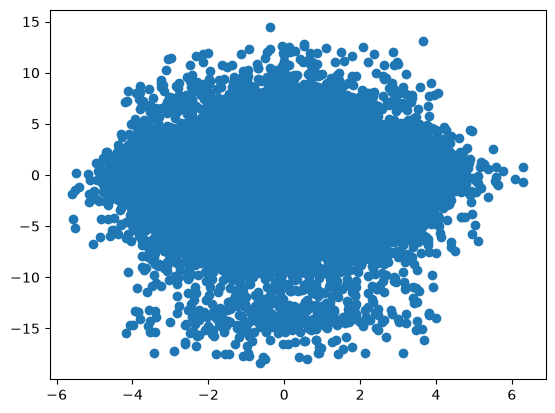

imb_d3 shape: (1, 2)
┌──────────┬────────────────────────┐
│ imb_d3   ┆ forward_mid_return_bps │
│ ---      ┆ ---                    │
│ f64      ┆ f64                    │
╞══════════╪════════════════════════╡
│ 0.039669 ┆ 1.917456               │
└──────────┴────────────────────────┘


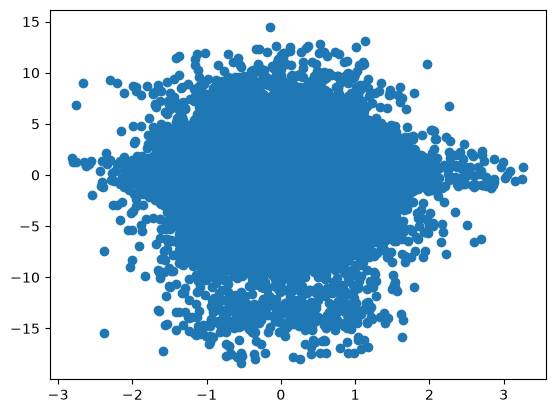

imb_d5 shape: (1, 2)
┌──────────┬────────────────────────┐
│ imb_d5   ┆ forward_mid_return_bps │
│ ---      ┆ ---                    │
│ f64      ┆ f64                    │
╞══════════╪════════════════════════╡
│ 0.038769 ┆ 1.917456               │
└──────────┴────────────────────────┘


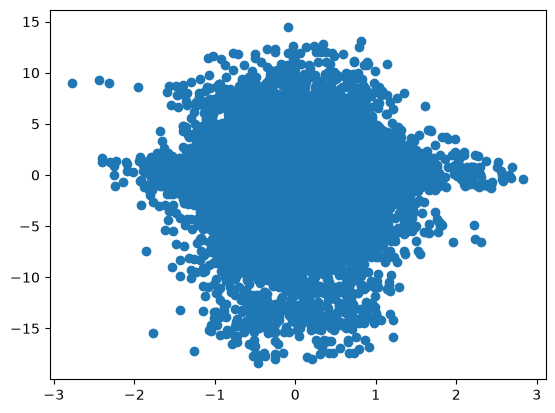

weighted_price_sz2 shape: (1, 2)
┌────────────────────┬────────────────────────┐
│ weighted_price_sz2 ┆ forward_mid_return_bps │
│ ---                ┆ ---                    │
│ f64                ┆ f64                    │
╞════════════════════╪════════════════════════╡
│ 0.01718            ┆ 1.917456               │
└────────────────────┴────────────────────────┘


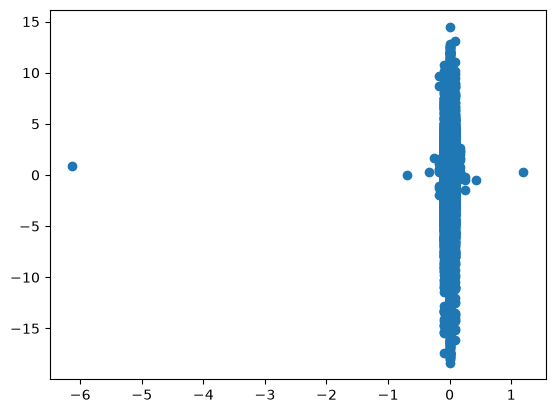

weighted_price_sz5 shape: (1, 2)
┌────────────────────┬────────────────────────┐
│ weighted_price_sz5 ┆ forward_mid_return_bps │
│ ---                ┆ ---                    │
│ f64                ┆ f64                    │
╞════════════════════╪════════════════════════╡
│ 0.025263           ┆ 1.917456               │
└────────────────────┴────────────────────────┘


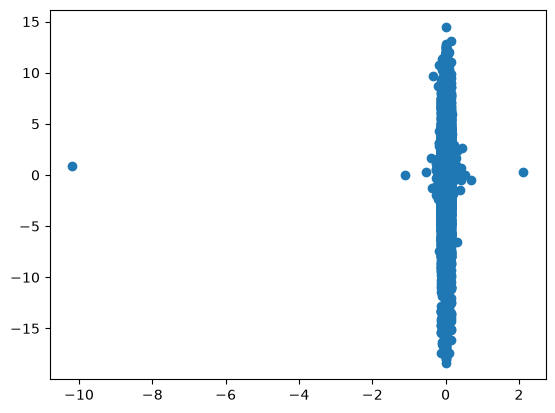

weighted_price_sz10 shape: (1, 2)
┌─────────────────────┬────────────────────────┐
│ weighted_price_sz10 ┆ forward_mid_return_bps │
│ ---                 ┆ ---                    │
│ f64                 ┆ f64                    │
╞═════════════════════╪════════════════════════╡
│ 0.028512            ┆ 1.917456               │
└─────────────────────┴────────────────────────┘


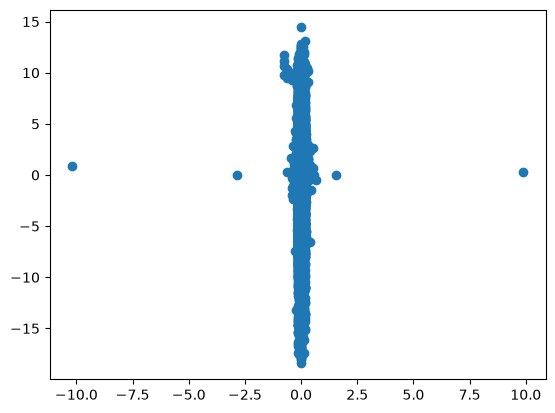

trade_momentum_hl1s shape: (1, 2)
┌─────────────────────┬────────────────────────┐
│ trade_momentum_hl1s ┆ forward_mid_return_bps │
│ ---                 ┆ ---                    │
│ f64                 ┆ f64                    │
╞═════════════════════╪════════════════════════╡
│ -0.01151            ┆ 1.917456               │
└─────────────────────┴────────────────────────┘


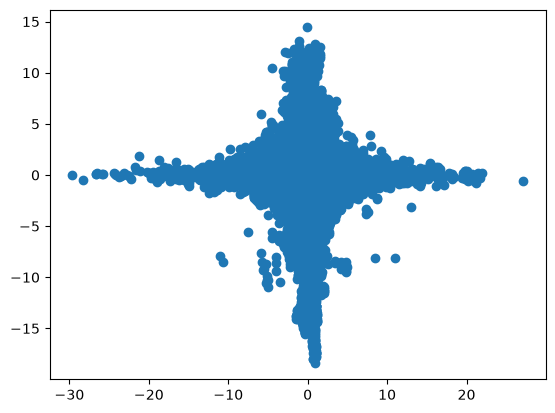

trade_momentum_hl10s shape: (1, 2)
┌──────────────────────┬────────────────────────┐
│ trade_momentum_hl10s ┆ forward_mid_return_bps │
│ ---                  ┆ ---                    │
│ f64                  ┆ f64                    │
╞══════════════════════╪════════════════════════╡
│ 0.000359             ┆ 1.917456               │
└──────────────────────┴────────────────────────┘


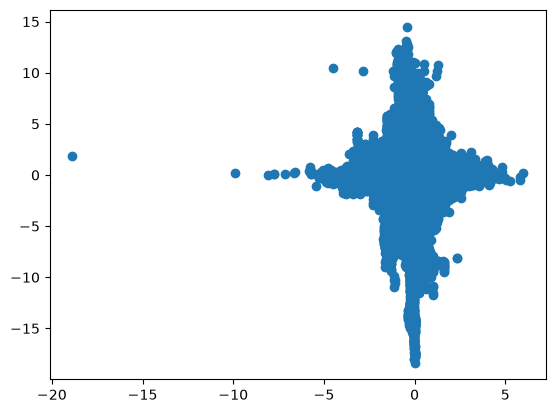

trade_momentum_hl30s shape: (1, 2)
┌──────────────────────┬────────────────────────┐
│ trade_momentum_hl30s ┆ forward_mid_return_bps │
│ ---                  ┆ ---                    │
│ f64                  ┆ f64                    │
╞══════════════════════╪════════════════════════╡
│ 0.012498             ┆ 1.917456               │
└──────────────────────┴────────────────────────┘


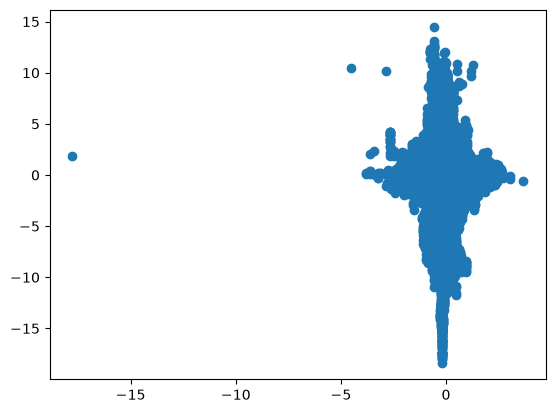

trade_momentum_hl120s shape: (1, 2)
┌───────────────────────┬────────────────────────┐
│ trade_momentum_hl120s ┆ forward_mid_return_bps │
│ ---                   ┆ ---                    │
│ f64                   ┆ f64                    │
╞═══════════════════════╪════════════════════════╡
│ 0.035744              ┆ 1.917456               │
└───────────────────────┴────────────────────────┘


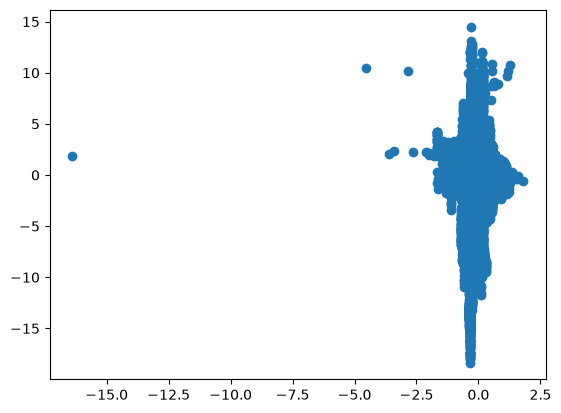

In [8]:
from matplotlib import pyplot as plt
import numpy as np
corr = np.zeros((len(FEATURES), len(FEATURES)))
for i in range(len(FEATURES)):
    for j in range(len(FEATURES)):
        f = FEATURES[i]
        f1 = FEATURES[j]
        corr[i, j] = df.select(pl.corr(pl.col(f), pl.col(f1)))[0].item()
print(corr)
for f in FEATURES:
    print(f, df.select(pl.corr(pl.col(f), pl.col(TARGET)), pl.col(TARGET).std()))
    plt.scatter(df[f], df[TARGET])
    plt.show()

In [9]:
train_result = pipeline.train(verbose=2)
train_result


/home/jli/projects/rep/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
[I 2026-06-28 12:05:06,482] A new study created in memory with name: no-name-8a88b34b-ecd4-416e-84d9-3efbb1940ed0


======== Optuna study created. Launching optimization.
======== running params {'alpha': 2.7898087272826135}
======== fold: 0, with train = ['2026-05-01', '2026-05-04', '2026-05-05'] and val = ['2026-05-06']
======== loss = 1.3034054989296016, running average = 1.3034054989296016
======== fold: 1, with train = ['2026-05-01', '2026-05-04', '2026-05-05', '2026-05-06'] and val = ['2026-05-07']


[I 2026-06-28 12:09:36,451] Trial 0 finished with value: 1.7472778153576445 and parameters: {'alpha': 2.7898087272826135}. Best is trial 0 with value: 1.7472778153576445.


======== loss = 1.9716167915591654, running average = 1.7472778153576445
======== running params {'alpha': 0.058014484781840445}
======== fold: 0, with train = ['2026-05-01', '2026-05-04', '2026-05-05'] and val = ['2026-05-06']
======== loss = 1.3007623378623991, running average = 1.3007623378623991
======== fold: 1, with train = ['2026-05-01', '2026-05-04', '2026-05-05', '2026-05-06'] and val = ['2026-05-07']


[I 2026-06-28 12:10:19,192] Trial 1 finished with value: 1.7449794198097688 and parameters: {'alpha': 0.058014484781840445}. Best is trial 1 with value: 1.7449794198097688.


...

[I 2026-06-28 12:11:43,133] Trial 3 finished with value: 1.7472778153576445 and parameters: {'alpha': 0.6654545553227136}. Best is trial 2 with value: 1.7443095594815636.


======== loss = 1.9716167915591654, running average = 1.7472778153576445
======== running params {'alpha': 0.012279052507215555}
======== fold: 0, with train = ['2026-05-01', '2026-05-04', '2026-05-05'] and val = ['2026-05-06']
======== loss = 1.306526210086164, running average = 1.306526210086164
======== fold: 1, with train = ['2026-05-01', '2026-05-04', '2026-05-05', '2026-05-06'] and val = ['2026-05-07']


[I 2026-06-28 12:12:26,860] Trial 4 finished with value: 1.7444190309402314 and parameters: {'alpha': 0.012279052507215555}. Best is trial 2 with value: 1.7443095594815636.


======== loss = 1.965735890497799, running average = 1.7444190309402314
======== optimization finished, best params extracted. Refitting with best params.
======== training done.


{'best_params': {'alpha': 0.03409489089695484},
 'best_score': 1.7443095594815636,
 'n_trials': 5,
 'validation_history': [{'trial': 0,
   'fold': 0,
   'val_score': 1.3034054989296016,
   'weighted_score': 1.3034054989296016,
   'n': 6397035,
   'dates': ['2026-05-06'],
   'natures': ['normal'],
   'params': {'alpha': 2.7898087272826135}},
  {'trial': 0,
   'fold': 1,
   'val_score': 1.9716167915591654,
   'weighted_score': 1.7472778153576445,
   'n': 10045897,
   'dates': ['2026-05-07'],
   'natures': ['normal'],
   'params': {'alpha': 2.7898087272826135}},
  {'trial': 1,
   'fold': 0,
   'val_score': 1.3007623378623991,
   'weighted_score': 1.3007623378623991,
   'n': 6397035,
   'dates': ['2026-05-06'],
   'natures': ['normal'],
   'params': {'alpha': 0.058014484781840445}},
  {'trial': 1,
   'fold': 1,
   'val_score': 1.9694926450932275,
   'weighted_score': 1.7449794198097688,
   'n': 10045897,
   'dates': ['2026-05-07'],
   'natures': ['normal'],
   'params': {'alpha': 0.0580144

In [14]:
test_result = pipeline.test(get_unit_pnl(0.0))
test_result


{'test_score': 0.048878408237615356,
 'n': 6397035,
 'ctx': {'n': 6397035,
  'dates': ['2026-05-06'],
  'natures': ['normal'],
  'fold': 'test'},
 'y_pred': array([ 0.10156337, -0.02278802,  0.01167782, ..., -0.00964973,
        -0.00965132, -0.00991928], shape=(6397035,))}

In [16]:
test_result = pipeline.test(get_unit_pnl(0.1))
test_result


{'test_score': 0.02852047701374494,
 'n': 6397035,
 'ctx': {'n': 6397035,
  'dates': ['2026-05-06'],
  'natures': ['normal'],
  'fold': 'test'},
 'y_pred': array([ 0.10156337, -0.02278802,  0.01167782, ..., -0.00964973,
        -0.00965132, -0.00991928], shape=(6397035,))}

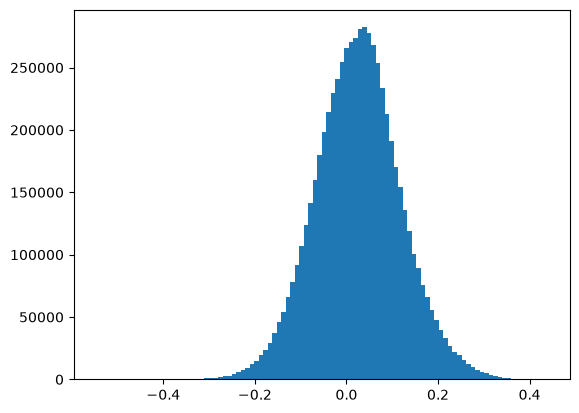

In [15]:
# path = pipeline.adapter.path(pipeline.model)
# {k: (v.shape if hasattr(v, "shape") else len(v)) for k, v in path.items()}
_ = plt.hist(test_result['y_pred'], bins=100)

In [12]:
model = pipeline.get_model()
transform = pipeline.fitted_transform

if model is None or model.coef is None:
    raise RuntimeError("Run pipeline.train() before inspecting coefficients.")
if transform is None or transform.means is None or transform.stds is None:
    raise RuntimeError("Run pipeline.train() with a fitted Standardizer before inspecting real coefficients.")

features = list(pipeline.features)
raw_coef = [float(coef) for coef in model.coef]
means = [float(transform.means[feature]) for feature in features]
stds = [float(transform.stds[feature]) for feature in features]
real_coef = [coef / std for coef, std in zip(raw_coef, stds)]

raw_intercept = float(model.intercept)
real_intercept = raw_intercept - sum(
    coef * mean / std for coef, mean, std in zip(raw_coef, means, stds)
)

df_coef = pl.DataFrame(
    [
        {
            "term": "intercept",
            "raw_coef": raw_intercept,
            "real_coef": real_intercept,
            "standardizer_mean": None,
            "standardizer_std": None,
        },
        *[
            {
                "term": feature,
                "raw_coef": raw,
                "real_coef": real,
                "standardizer_mean": mean,
                "standardizer_std": std,
            }
            for feature, raw, real, mean, std in zip(features, raw_coef, real_coef, means, stds)
        ],
    ]
)


In [13]:
df_coef

term,raw_coef,real_coef,standardizer_mean,standardizer_std
str,f64,f64,f64,f64
"""intercept""",0.0,0.00302,null,null
"""imb_d1""",0.053972,0.020799,0.007955,2.594972
"""imb_d3""",0.023694,0.028568,-0.011234,0.829397
"""imb_d5""",0.0,0.0,-0.015545,0.641282
"""weighted_price_sz2""",0.0,0.0,0.000293,0.048424
…,…,…,…,…
"""weighted_price_sz10""",0.017099,0.149495,0.001084,0.11438
"""trade_momentum_hl1s""",0.0,0.0,0.015988,1.484084
"""trade_momentum_hl10s""",-0.016326,-0.024997,-0.004686,0.653113
